In [2]:
import pickle

from pandas import Timedelta
import pandas as pd

from config import PATHS
from config.intervals import SEGMENT
from cycle_extraction.cycle_extraction_old import map_szrs_to_interval_index
from cycle_extraction.cycle_functions import nc_filter, compute_plv
from feature_extraction.extract_features import FeatureNames

In [22]:
pdir = PATHS.patient_dirs()[1]
print(pdir.name)

szrs = pd.read_pickle(pdir.all_szr_starts_file.pickle)
szrs = szrs[['start_mtz']]
segs = pd.read_pickle(pdir.segments_table.pickle)

with open(pdir.filled_features_for_segs.pickle, 'rb') as f:
    feature_chunks = pickle.load(f)

competition-1


In [3]:
for features in feature_chunks:
    features = features[FeatureNames.CYCLES]

features.head()

,acfw_D,acfw_P,var_D,var_P
0,9.0,10.0,15.731357,44.277487
1,21.0,1.0,19.308111,44.277487
2,21.0,10.0,78.619963,86.045538
3,9.0,1.0,78.619963,86.045538
4,21.0,1.0,19.308111,42.918956


In [4]:
segs_per_hour = Timedelta(seconds=3600) / SEGMENT.exact_dur
print(segs_per_hour)

240.03600540081013


['acfw_D', 'acfw_P', 'var_D', 'var_P']


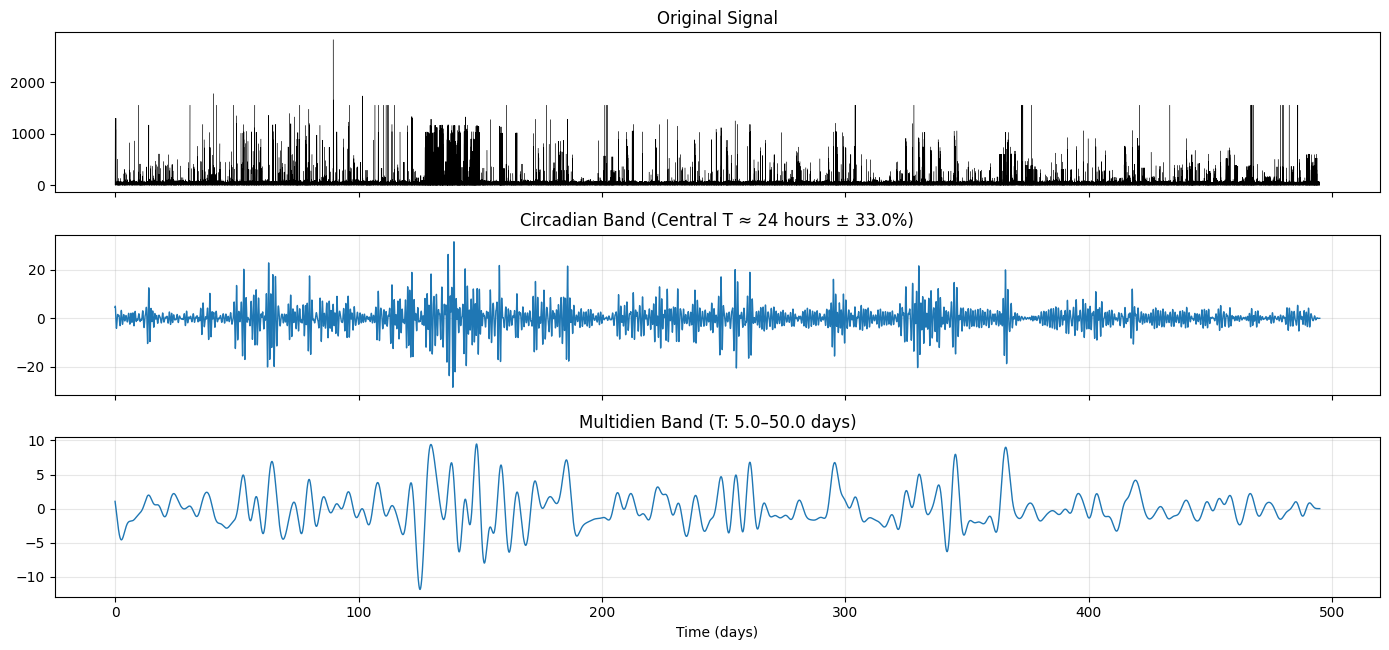

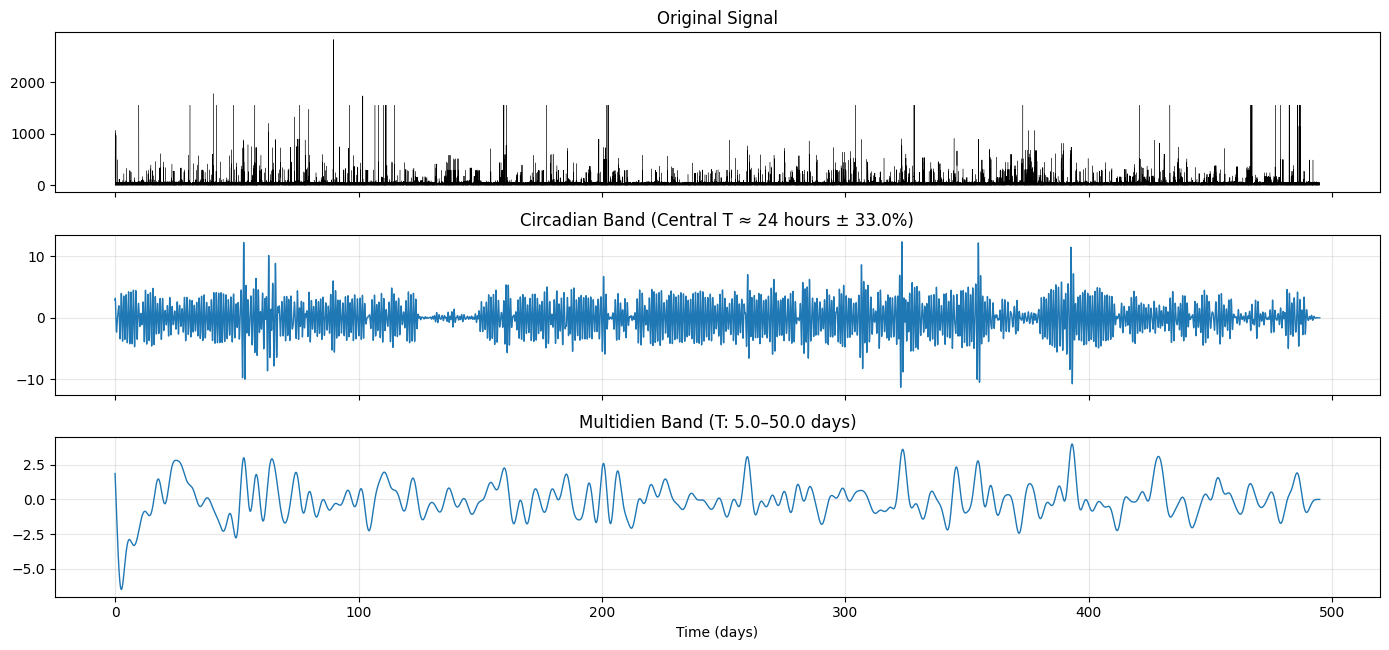

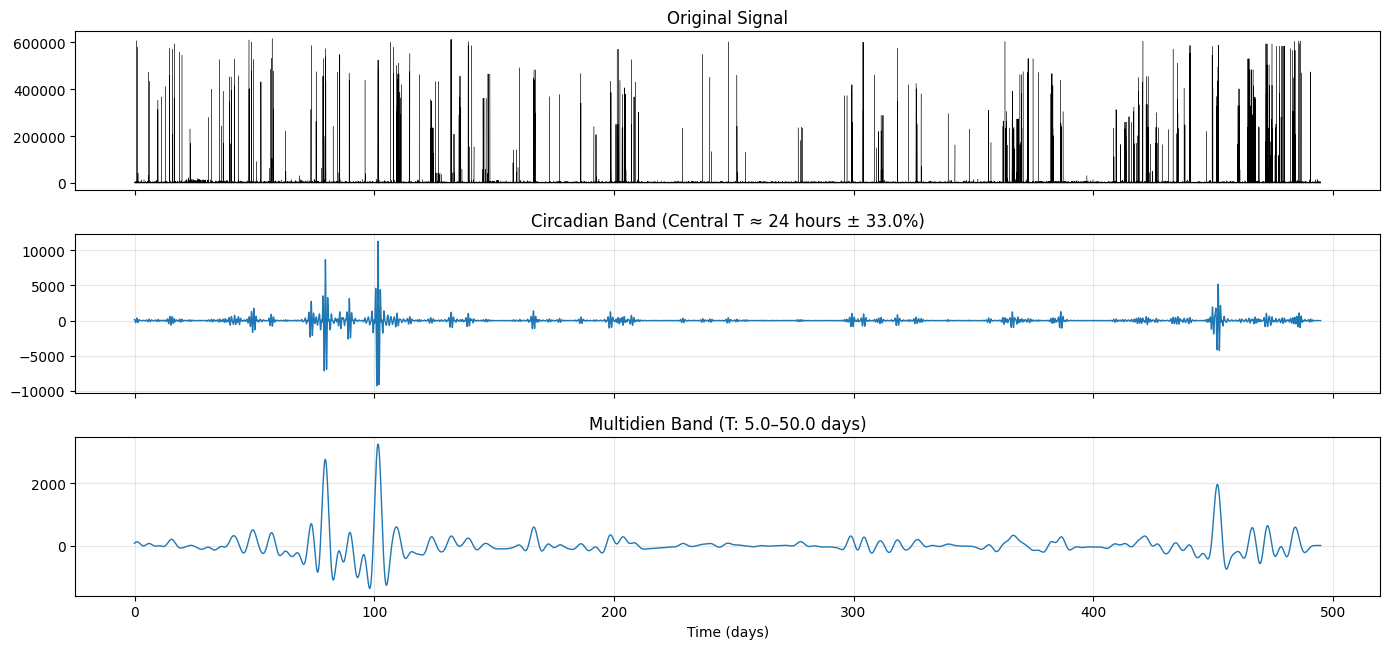

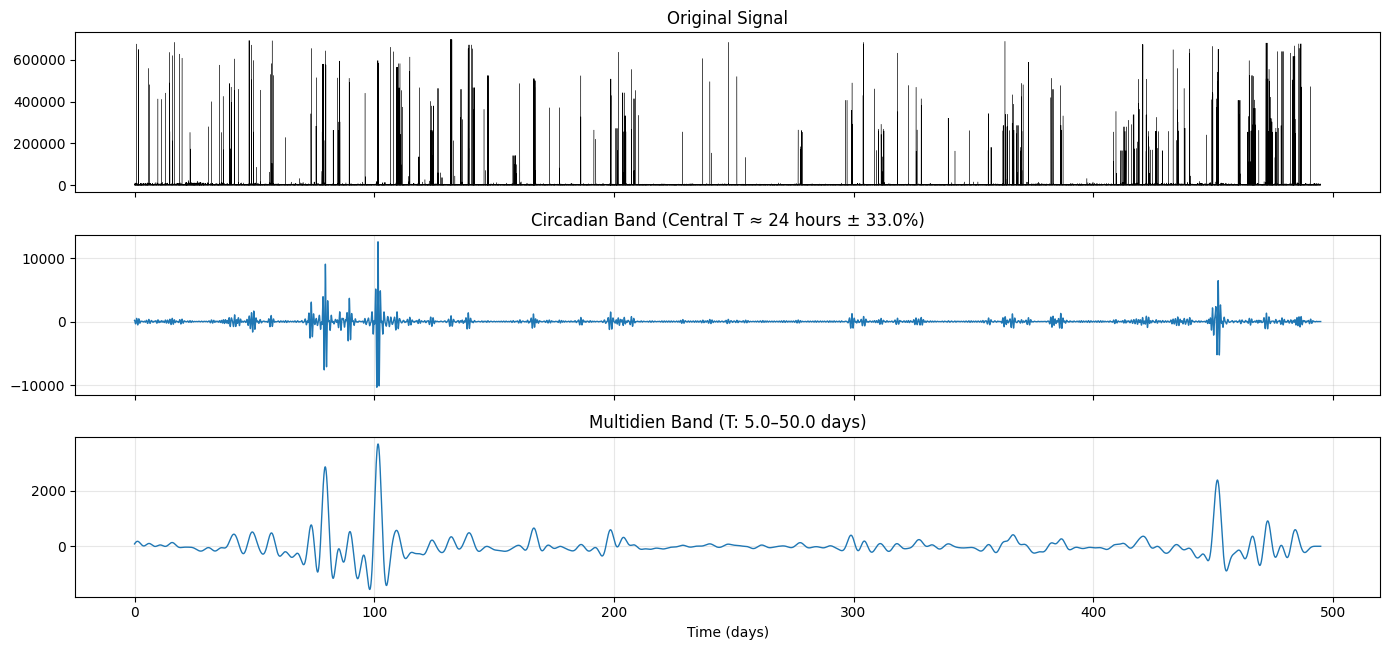

In [5]:
print(FeatureNames.CYCLES)

filtered = features.copy()

for col in features.columns:
    res = nc_filter(features[col], fs=segs_per_hour)
    filtered[col] = res['multidien']

In [6]:
# Map Seizures to windows (segments/clips)
szrs.head()

0   2020-11-12 00:42:14.028
1   2020-11-12 00:49:37.594
2   2020-11-12 06:00:05.374
3   2020-11-23 07:22:11.910
4   2020-11-23 08:19:25.406
Name: start_mtz, dtype: datetime64[ns]

In [26]:
segs = segs[['start_mtz']].copy()
segs['end_mtz'] = segs['start_mtz'] + SEGMENT.exact_dur
segs.head()


,start_mtz,end_mtz
0,2020-11-04 14:26:59.000000,2020-11-04 14:27:13.997750
1,2020-11-04 14:27:13.997750,2020-11-04 14:27:28.995500
2,2020-11-04 14:27:28.995500,2020-11-04 14:27:43.993250
3,2020-11-04 14:27:43.993250,2020-11-04 14:27:58.991000
4,2020-11-04 14:27:58.991000,2020-11-04 14:28:13.988750


In [27]:
szrs.head()
type(szrs)

pandas.core.frame.DataFrame

In [28]:
szrs['seg_idx'] = map_szrs_to_interval_index(szrs['start_mtz'], segs['start_mtz'], segs['end_mtz'])
szrs.head()

,start_mtz,seg_idx
0,2020-11-12 00:42:14.028,42787
1,2020-11-12 00:49:37.594,42816
2,2020-11-12 06:00:05.374,44059
3,2020-11-23 07:22:11.910,107757
4,2020-11-23 08:19:25.406,107985


In [ ]:
for col in features.columns:
    plv, mean_angle, mean_angle_deg, event_phases = compute_plv(filtered[col], szrs['seg_idx'], len(szrs))
    print(f'---- {col} ----')
    print(f'{plv=:.2f}\n{mean_angle=:.2f}\n{mean_angle_deg=:.2f}\n')


# Extract Averages per Segment

In [15]:
import numpy as np
import pandas as pd

In [16]:
clip_starts = np.array([0,  5, 15, 25, 30])
clip_ends   = np.array([4, 14, 24, 29, 35])
segs_idx = np.arange(0, 36)

In [19]:
clips = pd.DataFrame({'start_seg': clip_starts, 'end_seg': clip_ends})
segs = pd.DataFrame({'feature1': np.arange(100, 100+len(segs_idx)), 'feature2': np.arange(200, 200+len(segs_idx))}, index=segs_idx)
segs.loc[4, :] = pd.NA

In [20]:
clip_id = np.searchsorted(clips['start_seg'], segs.index, side='right') - 1
# segs['clip_id'] = clip_id
segs

,feature1,feature2
0,100.0,200.0
1,101.0,201.0
2,102.0,202.0
3,103.0,203.0
4,NaN,NaN
5,105.0,205.0
6,106.0,206.0
7,107.0,207.0
8,108.0,208.0
9,109.0,209.0


In [22]:
# Exclude nan values
has_na = segs['feature1'].isna().groupby(clip_id).any()
has_na

0     True
1    False
2    False
3    False
4    False
Name: feature1, dtype: bool

In [23]:
medians = segs.groupby(clip_id).median()
medians[has_na] = pd.NA
medians

,feature1,feature2
0,NaN,NaN
1,109.5,209.5
2,119.5,219.5
3,127.0,227.0
4,132.5,232.5


In [10]:
clips['feature1'] = medians['feature1']
clips


,start_seg,end_seg,feature1
0,0,4,NaN
1,5,14,109.5
2,15,24,119.5
3,25,29,127.0
4,30,35,132.5


# Split by NA

In [8]:
ser = pd.Series([0, 1, pd.NA, pd.NA, 4, 5, pd.NA, 7])
ser

0       0
1       1
2    <NA>
3    <NA>
4       4
5       5
6    <NA>
7       7
dtype: object

In [9]:
gap = ser.isna()
run_id = gap.ne(gap.shift(fill_value=False)).cumsum()
run_id

0    0
1    0
2    1
3    1
4    2
5    2
6    3
7    4
dtype: int64

In [11]:
chunks = [chunk for _, chunk in ser.groupby(run_id) if not chunk.isna().all()]
chunks

[0    0
 1    1
 dtype: object,
 4    4
 5    5
 dtype: object,
 7    7
 dtype: object]

In [15]:
df = pd.DataFrame({'a': ser+10, 'b':ser+20})
df

,a,b
0,10,20
1,11,21
2,<NA>,<NA>
3,<NA>,<NA>
4,14,24
5,15,25
6,<NA>,<NA>
7,17,27


In [16]:
gaps = df.isna().all(axis=1)
gaps

0    False
1    False
2     True
3     True
4    False
5    False
6     True
7    False
dtype: bool

In [17]:
run_id = gap.ne(gap.shift(fill_value=False)).cumsum()
run_id

0    0
1    0
2    1
3    1
4    2
5    2
6    3
7    4
dtype: int64

In [27]:
chunks = [c for _,c in df.groupby(run_id) if not c.isna().to_numpy().any()]
chunks

[    a   b
 0  10  20
 1  11  21,
     a   b
 4  14  24
 5  15  25,
     a   b
 7  17  27]

In [19]:
for _, c in df.groupby(run_id):
    print (c)

    a   b
0  10  20
1  11  21
      a     b
2  <NA>  <NA>
3  <NA>  <NA>
    a   b
4  14  24
5  15  25
      a     b
6  <NA>  <NA>
    a   b
7  17  27


In [25]:
c.isna().to_numpy().any()

np.False_